# Preprocessing

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Define data folder
data_folder = "data/"

# Define tract prefixes
treatment_prefixes = ["48113"]
control_prefixes = ["48201"]

# Define years
years = list(range(2014, 2023))

# Columns to keep
columns_to_keep = [
    "program_label",
    "program",
    "entities",
    "code",
    "number_reported",
    "rent_per_month",
    "hh_income",
    "tpoverty",
    "pct_minority",
    "pct_black_nonhsp",
    "pct_native_american_nonhsp",
    "pct_asian_pacific_nonhsp",
    "pct_white_nothsp",
    "pct_black_hsp",
    "pct_wht_hsp",
    "pct_oth_hsp",
    "pct_hispanic",
    "pct_multi",
]

# HUD missing codes
missing_codes = ["-1", "-4", "-5", "NA"]

## 2. Helper Functions

In [17]:
def filter_tracts(df, treatment_prefixes, control_prefixes, file_name="unknown"):
    """
    Create treatment indicator and filter tracts.

    treatment = 1 if tract code starts with any treatment prefix
    treatment = 0 otherwise

    Keeps only rows belonging to treatment or control prefix groups.
    """
    try:
        df["code"] = df["code"].astype(str)

        # Create treatment indicator
        df["treatment"] = 0

        treatment_mask = df["code"].str.startswith(tuple(treatment_prefixes))
        df.loc[treatment_mask, "treatment"] = 1

        # Keep only treatment + control tracts
        valid_prefixes = tuple(treatment_prefixes + control_prefixes)
        df = df[df["code"].str.startswith(valid_prefixes)]

        return df

    except Exception as e:
        print(f"Error in filter_tracts for file: {file_name}")
        print(e)
        return df


def processing_missing_values(df, file_name="unknown"):
    """
    Handle HUD-specific missing values and numeric conversion.

    Converts number_reported to numeric, applies suppression rule (<11 → -4),
    replaces special codes with NaN, and converts all numeric columns.
    """
    try:
        df["number_reported"] = pd.to_numeric(df["number_reported"], errors="coerce")

        # Apply suppression rule
        df.loc[df["number_reported"] < 11, "number_reported"] = -4

        # Replace HUD missing codes
        df = df.replace(missing_codes, np.nan)

        numeric_cols = [
            "number_reported",
            "rent_per_month",
            "hh_income",
            "tpoverty",
            "pct_minority",
            "pct_black_nonhsp",
            "pct_native_american_nonhsp",
            "pct_asian_pacific_nonhsp",
            "pct_white_nothsp",
            "pct_black_hsp",
            "pct_wht_hsp",
            "pct_oth_hsp",
            "pct_hispanic",
            "pct_multi",
        ]

        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        return df

    except Exception as e:
        print(f"Error in processing_missing_values for file: {file_name}")
        print(e)
        return df


def add_year(df, year):
    """
    Add year column.
    """
    df["year"] = year
    return df


def create_variables(df):
    """
    Create analysis variables.

    post = 1 for 2018+
    poverty_indicator = 1 if poverty >= 30%
    """
    df["post"] = (df["year"] >= 2018).astype(int)
    df["poverty_indicator"] = (df["tpoverty"] >= 30).astype(int)

    return df

## 3. Process Data

In [18]:
df_list = []

for year in years:
    pattern = os.path.join(data_folder, f"TRACT_*_{year}.xlsx")
    files = glob.glob(pattern)

    for file in files:
        try:
            print(f"Processing file: {file}")

            # Load file
            df = pd.read_excel(file, dtype=str)

            # Filter to HCV program
            df = df[df["program"] == "3"]

            # Keep only needed columns
            df = df[[col for col in columns_to_keep if col in df.columns]]

            # Filter tracts and assign treatment
            df = filter_tracts(df, treatment_prefixes, control_prefixes, file)

            # Process missing values
            df = processing_missing_values(df, file)

            # Add year
            df = add_year(df, year)

            # Warn if dataset becomes empty
            if df.empty:
                print(f"Warning: {file} resulted in empty dataframe after filtering")

            df_list.append(df)

        except Exception as e:
            print(f"Error processing file: {file} in main loop")
            print(e)

# Combine all files
panel_df = pd.concat(df_list, ignore_index=True)

# Create derived variables
panel_df = create_variables(panel_df)

Processing file: data\TRACT_MO_WY_2014.xlsx
Processing file: data\TRACT_MO_WY_2015.xlsx
Processing file: data\TRACT_MO_WY_2016.xlsx
Processing file: data\TRACT_MO_WY_2017.xlsx
Processing file: data\TRACT_MO_WY_2018.xlsx
Processing file: data\TRACT_MO_WY_2019.xlsx
Processing file: data\TRACT_MO_WY_2020.xlsx
Processing file: data\TRACT_MO_WY_2021.xlsx
Processing file: data\TRACT_MO_WY_2022.xlsx


In [21]:
panel_df.head()

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,pct_minority,pct_black_nonhsp,...,pct_white_nothsp,pct_black_hsp,pct_wht_hsp,pct_oth_hsp,pct_hispanic,pct_multi,treatment,year,post,poverty_indicator
0,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000100,48113000100,-4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,2014,0,0
1,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000401,48113000401,39,297.0,11131.0,38.0,92.0,5.0,...,8.0,NaN,3.0,3.0,5.0,0.0,1,2014,0,1
2,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000404,48113000404,-4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,2014,0,0
3,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000405,48113000405,17,268.0,10446.0,40.0,59.0,24.0,...,41.0,NaN,6.0,NaN,6.0,0.0,1,2014,0,1
4,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000406,48113000406,-4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,2014,0,0


## 4. Exploratory Data Analysis

In [11]:
# Check for missingness in entire dataset
missing_summary = panel_df.isna().mean().sort_values(ascending=False)
print("Missingness (percent):")
print(missing_summary)

Missingness (percent):
pct_native_american_nonhsp    0.933139
pct_oth_hsp                   0.904707
pct_asian_pacific_nonhsp      0.791085
pct_black_hsp                 0.747240
pct_white_nothsp              0.563633
pct_wht_hsp                   0.535513
pct_black_nonhsp              0.406374
hh_income                     0.404603
tpoverty                      0.404603
pct_multi                     0.404603
pct_hispanic                  0.404603
rent_per_month                0.404603
pct_minority                  0.404603
program_label                 0.000000
number_reported               0.000000
code                          0.000000
entities                      0.000000
program                       0.000000
treatment                     0.000000
year                          0.000000
post                          0.000000
poverty_indicator             0.000000
dtype: float64


In [16]:
# Check for missingness within each year
missing_by_year = panel_df.groupby("year").apply(lambda x: x.isna().mean())
print("Missingness by year:")
missing_by_year.iloc[:, :-1]

Missingness by year:


,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,pct_minority,pct_black_nonhsp,pct_native_american_nonhsp,pct_asian_pacific_nonhsp,pct_white_nothsp,pct_black_hsp,pct_wht_hsp,pct_oth_hsp,pct_hispanic,pct_multi,treatment,post
year,,,,,,,,,,,,,,,,,,,,
2014,0.0,0.0,0.0,0.0,0.0,0.375706,0.375706,0.375706,0.375706,0.379473,0.943503,0.771186,0.538606,0.757062,0.519774,0.885122,0.375706,0.375706,0.0,0.0
2015,0.0,0.0,0.0,0.0,0.0,0.385417,0.385417,0.385417,0.385417,0.388258,0.933712,0.769886,0.548295,0.732955,0.523674,0.895833,0.385417,0.385417,0.0,0.0
2016,0.0,0.0,0.0,0.0,0.0,0.396601,0.396601,0.396601,0.396601,0.398489,0.927290,0.775260,0.535411,0.735600,0.522191,0.894240,0.396601,0.396601,0.0,0.0
2017,0.0,0.0,0.0,0.0,0.0,0.404516,0.404516,0.404516,0.404516,0.406397,0.928504,0.790216,0.545626,0.746943,0.524929,0.910630,0.404516,0.404516,0.0,0.0
2018,0.0,0.0,0.0,0.0,0.0,0.404943,0.404943,0.404943,0.404943,0.406844,0.928707,0.794677,0.573194,0.749049,0.534221,0.907795,0.404943,0.404943,0.0,0.0
2019,0.0,0.0,0.0,0.0,0.0,0.405456,0.405456,0.405456,0.405456,0.407338,0.924741,0.791157,0.580433,0.748824,0.541863,0.904986,0.405456,0.405456,0.0,0.0
2020,0.0,0.0,0.0,0.0,0.0,0.408542,0.408542,0.408542,0.408542,0.409471,0.932219,0.800371,0.570102,0.750232,0.543175,0.907149,0.408542,0.408542,0.0,0.0
2021,0.0,0.0,0.0,0.0,0.0,0.432904,0.432904,0.432904,0.432904,0.432904,0.938419,0.813419,0.597426,0.757353,0.556066,0.916360,0.432904,0.432904,0.0,0.0
2022,0.0,0.0,0.0,0.0,0.0,0.426063,0.426063,0.426063,0.426063,0.426987,0.940850,0.812384,0.582255,0.746765,0.552680,0.919593,0.426063,0.426063,0.0,0.0


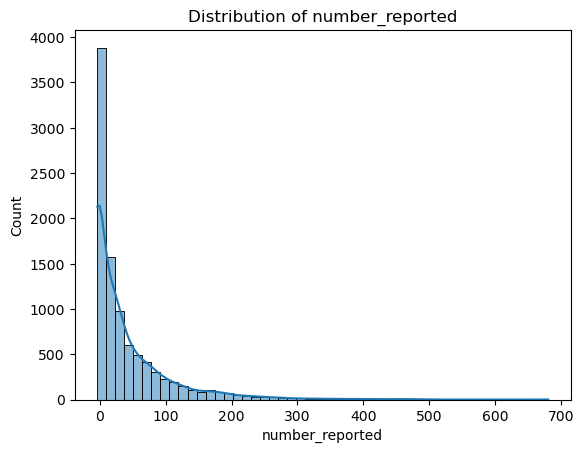

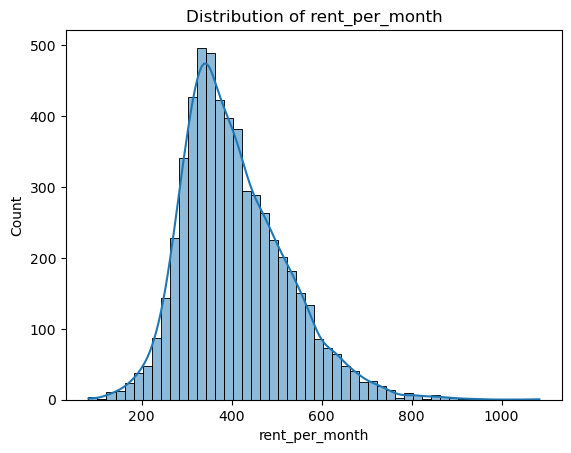

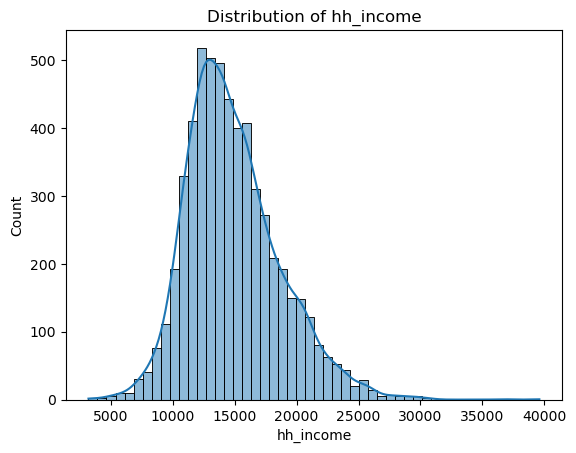

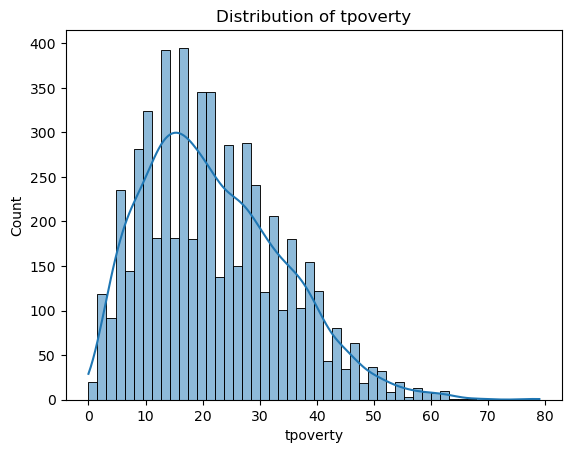

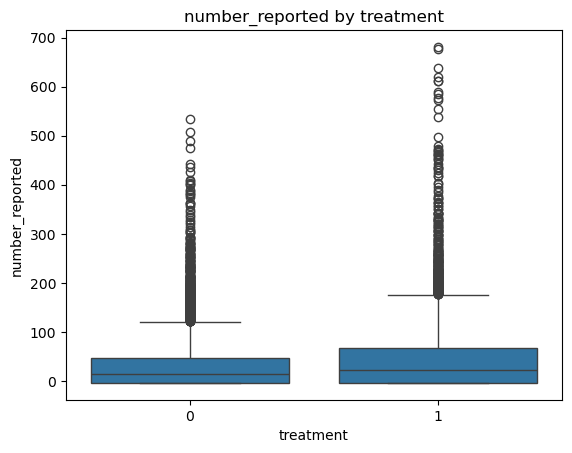

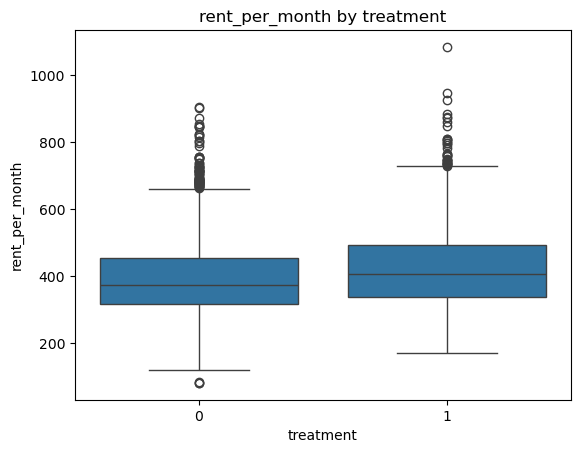

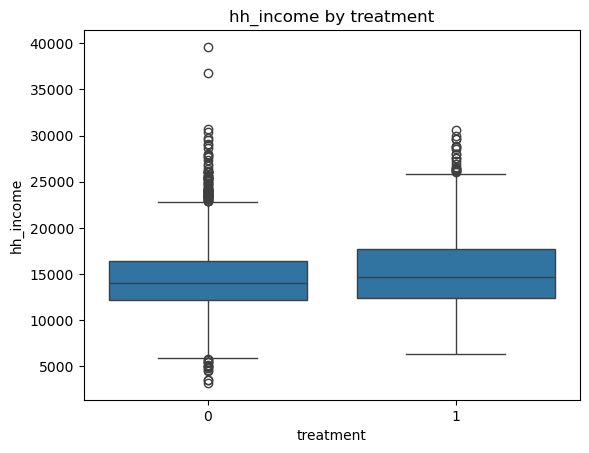

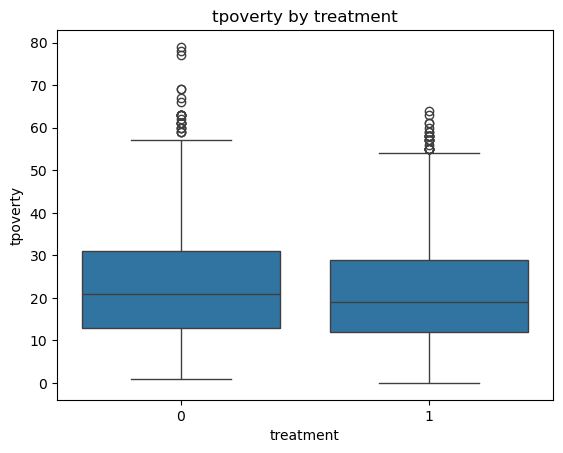

In [5]:
# Plot feature distribution

numeric_cols = ["number_reported", "rent_per_month", "hh_income", "tpoverty"]

# Histogram
for col in numeric_cols:
    plt.figure()
    sns.histplot(panel_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Boxplot
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x="treatment", y=col, data=panel_df)
    plt.title(f"{col} by treatment")
    plt.show()

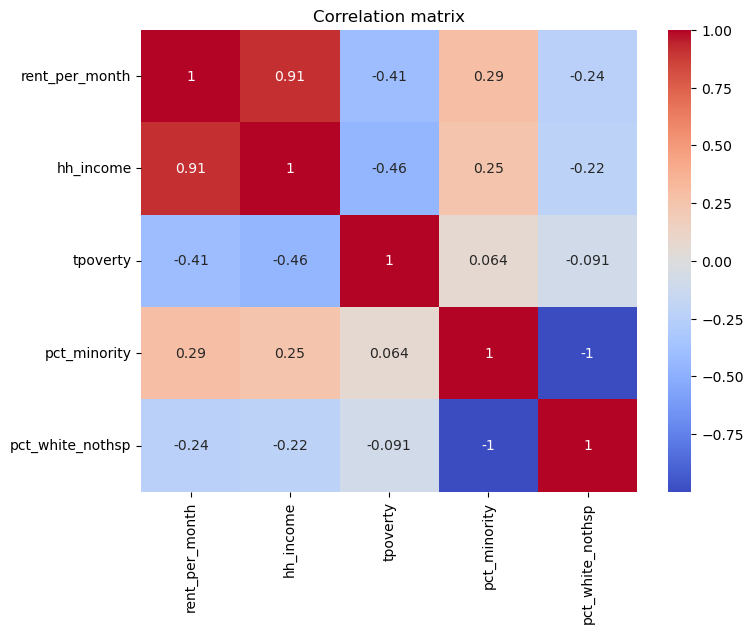

In [6]:
# Feature correlation heatmap
corr_vars = [
    "rent_per_month",
    "hh_income",
    "tpoverty",
    "pct_minority",
    "pct_white_nothsp",
]

plt.figure(figsize=(8, 6))
sns.heatmap(panel_df[corr_vars].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

## 5. Save Processed Dataset

In [7]:
output_path = os.path.join(data_folder, "clean_hcv_data.csv")
panel_df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: data/clean_hcv_data.csv
